### EDA on Hamed_master.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("../data/Hamed_master.csv")


df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE")

print(df.head())
print(df.columns)
print(df.shape)

        DATE  PCE_REAL  SAVING_RATE  CONSUMER_CREDIT      CPI  FEDFUNDS  \
0 2007-01-01   11181.0          2.4       2457945.58  203.437      5.25   
1 2007-02-01   11178.2          2.8       2470049.92  204.226      5.26   
2 2007-03-01   11190.7          3.0       2484433.18  205.288      5.26   
3 2007-04-01   11201.5          3.0       2493729.77  205.904      5.25   
4 2007-05-01   11218.0          2.8       2510016.06  206.755      5.25   

   REAL_DPI  
0   11956.6  
1   11996.0  
2   12035.1  
3   12052.8  
4   12059.9  
Index(['DATE', 'PCE_REAL', 'SAVING_RATE', 'CONSUMER_CREDIT', 'CPI', 'FEDFUNDS',
       'REAL_DPI'],
      dtype='object')
(229, 7)


In [2]:
print(df.describe())

                                DATE      PCE_REAL  SAVING_RATE  \
count                            229    229.000000   229.000000   
mean   2016-07-01 07:26:27.772925696  13207.887773     6.257205   
min              2007-01-01 00:00:00  11068.000000     1.900000   
25%              2011-10-01 00:00:00  11555.700000     5.100000   
50%              2016-07-01 00:00:00  12891.200000     5.700000   
75%              2021-04-01 00:00:00  14771.400000     6.600000   
max              2026-01-01 00:00:00  16715.400000    31.800000   
std                              NaN   1748.106030     3.444116   

       CONSUMER_CREDIT         CPI    FEDFUNDS      REAL_DPI  
count     2.290000e+02  229.000000  229.000000    229.000000  
mean      3.637535e+06  251.450825    1.575284  14639.595633  
min       2.457946e+06  203.437000    0.050000  11956.600000  
25%       2.727963e+06  226.750000    0.120000  12799.700000  
50%       3.542768e+06  240.222000    0.380000  14160.100000  
75%       4.207768

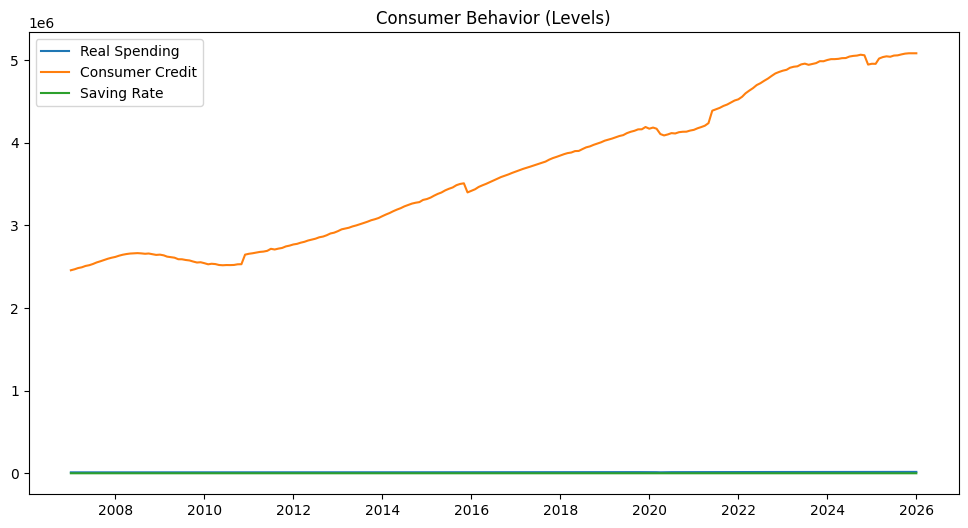

In [3]:
## EDA Chart
plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["PCE_REAL"], label="Real Spending")
plt.plot(df["DATE"], df["CONSUMER_CREDIT"], label="Consumer Credit")
plt.plot(df["DATE"], df["SAVING_RATE"], label="Saving Rate")

plt.legend()
plt.title("Consumer Behavior (Levels)")
plt.show()

Because these variables are in very different scales:

Consumer Credit ≈ millions

PCE ≈ ~10k–16k

Saving Rate ≈ 0–30%

- The credit line dominates the chart visually.
- Saving rate looks flat because of scale distortion.

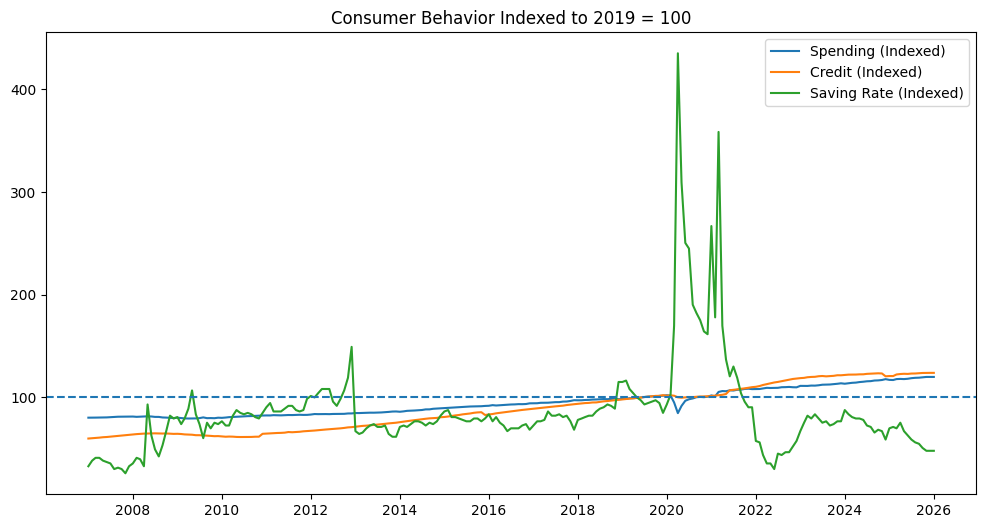

In [4]:
##Index Everything to 2019 = 

df_2019 = df[df["DATE"].dt.year == 2019]

base_pce = df_2019["PCE_REAL"].mean()
base_credit = df_2019["CONSUMER_CREDIT"].mean()
base_save = df_2019["SAVING_RATE"].mean()

df["PCE_INDEX"] = df["PCE_REAL"] / base_pce * 100
df["CREDIT_INDEX"] = df["CONSUMER_CREDIT"] / base_credit * 100
df["SAVE_INDEX"] = df["SAVING_RATE"] / base_save * 100

plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["PCE_INDEX"], label="Spending (Indexed)")
plt.plot(df["DATE"], df["CREDIT_INDEX"], label="Credit (Indexed)")
plt.plot(df["DATE"], df["SAVE_INDEX"], label="Saving Rate (Indexed)")

plt.axhline(100, linestyle="--")
plt.legend()
plt.title("Consumer Behavior Indexed to 2019 = 100")
plt.show()

# Economic Indicators Analysis

## Spending (Blue Line)

**What we see:**
- Sharp drop in 2020
- Very fast rebound
- After 2021 → spending stays **above 100**
- Continues gradual upward trend

**Key Insight:**
- Spending did **NOT** permanently collapse.
- In fact:
  - It rebounded and shifted slightly upward relative to 2019.
  - But the slope after 2022 does **NOT** look dramatically steeper than pre-COVID.

 *This suggests no obvious structural break in spending trend yet.*

## Consumer Credit (Orange Line)

**What we see:**
- Slight drop in 2020
- Strong acceleration after 2021
- By 2024–2026, it is clearly above **120** (vs 2019)
- The slope post-2022 looks steeper than pre-2020.

*This may indicate a structural acceleration in borrowing.*
*But we must confirm with growth rates later.*

## Saving Rate (Green Line)

This is the most dramatic:
- Huge spike in 2020 (**stimulus effect**)
- Then sharp collapse
- After 2022 → saving rate stays **below** 2019 level

### This is important:
- Before COVID → around **5–7% normal range**
- After inflation → lower than 2019 baseline

*This suggests potential structural decline in savings behavior.*
*This is our strongest candidate for “permanent change.”*

##  Preliminary Hypothesis (Don’t Conclude Yet)
Based only on indexed levels:
- Spending → temporary shock, not permanent break
- Credit → possibly accelerated borrowing regime
- Saving → potentially structurally lower
*But this is visual inspection only.*

##  Next Step: YoY Growth (This Confirms Structural Change)

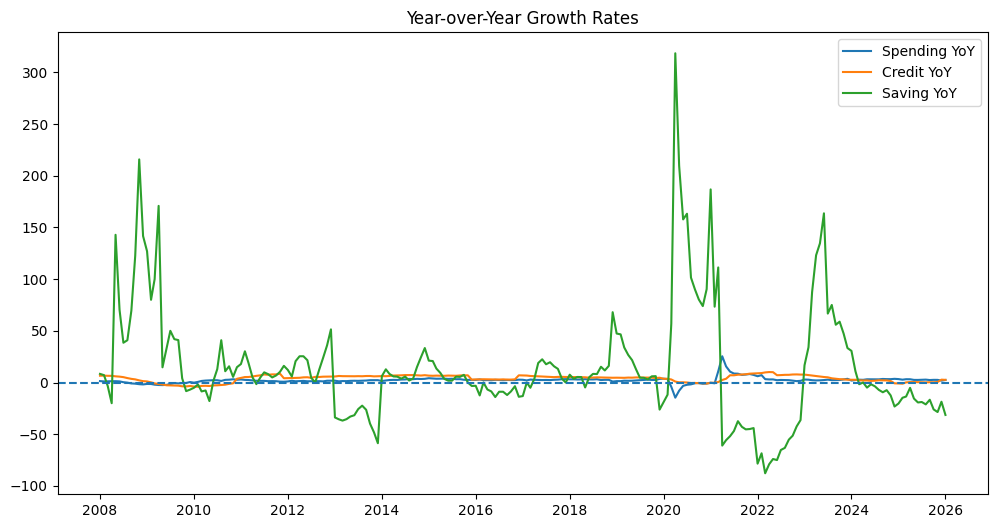

In [5]:
## Compute Year-over-Year Growth

df["PCE_YOY"] = df["PCE_REAL"].pct_change(12) * 100
df["CREDIT_YOY"] = df["CONSUMER_CREDIT"].pct_change(12) * 100
df["SAVE_YOY"] = df["SAVING_RATE"].pct_change(12) * 100

plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["PCE_YOY"], label="Spending YoY")
plt.plot(df["DATE"], df["CREDIT_YOY"], label="Credit YoY")
plt.plot(df["DATE"], df["SAVE_YOY"], label="Saving YoY")

plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Year-over-Year Growth Rates")
plt.show()

# Economic Data Analysis

##  Spending YoY (Blue)

**What we see:**
- Massive drop in 2020
- Huge rebound in 2021 (base effect)
- After 2022 → growth stabilizes
- Post-2022 growth looks similar to pre-2020 (around 2–5%)

**Interpretation:**
- Spending shows:
  - Temporary volatility
  - Then normalization

 There is **NO obvious permanent acceleration or collapse** in spending growth.

So far, spending does **NOT** look structurally changed.



##  Credit YoY (Orange)

**What we see:**
- Drop in 2020
- Strong acceleration from 2021 to 2023
- After 2023 → moderating back toward normal range
- Post-2024: Credit growth looks similar to historical pattern.

**Interpretation:**
- Credit surged during inflation + rate hikes,
but it does not appear permanently elevated.

This suggests:
- Borrowing behavior adjusted temporarily — not clearly permanently.



##  Saving YoY (Green)

**This is the unstable one.**

**What we see:**
- Massive volatility
- Huge positive spike in 2020
- Deep collapse in 2021–2022
- Continued instability through 2024–2025
- Even by 2026:
  - It hasn’t clearly returned to a stable regime.

**Interpretation:**
- Saving behavior appears structurally more unstable.
- This is our strongest candidate for structural change.



In [6]:
### Compare Pre vs Post Means
### Define:
### Pre-shock: 2007–2019
### Post-inflation: 2022–2026 (we skip 2020–2021 because they are shock years)


pre = df[(df["DATE"].dt.year >= 2007) & (df["DATE"].dt.year <= 2019)]
post = df[(df["DATE"].dt.year >= 2022)]

print("Spending YoY Mean")
print("Pre:", pre["PCE_YOY"].mean())
print("Post:", post["PCE_YOY"].mean())

print("\nCredit YoY Mean")
print("Pre:", pre["CREDIT_YOY"].mean())
print("Post:", post["CREDIT_YOY"].mean())

print("\nSaving YoY Mean")
print("Pre:", pre["SAVE_YOY"].mean())
print("Post:", post["SAVE_YOY"].mean())

Spending YoY Mean
Pre: 1.8140335757684447
Post: 2.8003802891567458

Credit YoY Mean
Pre: 4.165229052703378
Post: 3.843081213793613

Saving YoY Mean
Pre: 14.10356065807387
Post: -3.26449047963306


# Economic Indicators Analysis

## Spending (PCE YoY)

**Pre:** 1.81%  
**Post:** 2.80%

### Interpretation:

- Spending growth is slightly higher post-inflation.
- But:
  - Difference ≈ 1 percentage point
  - Not dramatic
- Could reflect income growth or price normalization effects
- No strong evidence of a structural break here.
- Spending appears resilient.

## Credit (YoY)

**Pre:** 4.16%  
**Post:** 3.84%

### Interpretation:

- Credit growth is actually slightly LOWER post-2022.
- So despite inflation + rate hikes:
  - Borrowing growth is not permanently elevated.
- No structural acceleration in borrowing.

## Saving (YoY) — This Is Big

**Pre:** +14.1% average YoY  
**Post:** –3.26% average YoY

### Key Insights:
- That is a major regime shift.
- Pre period: Savings generally growing.
- Post period: Savings shrinking.
- This aligns with what we saw visually:
  - Saving rate collapsed after stimulus.
  - Has not returned to previous growth behavior.
- This is our strongest candidate for structural change.

## Modeling (Counterfactual Forecast for Spending)
#### Train on pre-shock data (2007–2019), then forecast 2020–2026 and compare forecast vs actual.

In [7]:
## Create train/test split (pre vs post)

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make sure DATE is datetime
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE").reset_index(drop=True)

# Create a simple time index feature
df["t"] = np.arange(len(df))

# Train: 2007–2019
train = df[df["DATE"].dt.year <= 2019].copy()

# Test/Forecast window: 2020+
test = df[df["DATE"].dt.year >= 2020].copy()

print(train.shape, test.shape)
print(train["DATE"].min(), train["DATE"].max())
print(test["DATE"].min(), test["DATE"].max())

(156, 14) (73, 14)
2007-01-01 00:00:00 2019-12-01 00:00:00
2020-01-01 00:00:00 2026-01-01 00:00:00


In [8]:
# Select features + train Linear Regression
features = ["t", "CPI", "FEDFUNDS", "REAL_DPI"]
target = "PCE_REAL"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

model = LinearRegression()
model.fit(X_train, y_train)

pred_test = model.predict(X_test)

print("Coefficients:", dict(zip(features, model.coef_)))
print("Intercept:", model.intercept_)

Coefficients: {'t': np.float64(16.239101546619793), 'CPI': np.float64(-10.19963569836925), 'FEDFUNDS': np.float64(116.47016562916326), 'REAL_DPI': np.float64(0.3321130773357293)}
Intercept: 8733.745196242544


In [9]:
## Evaluate forecast error (post period)
mae = mean_absolute_error(y_test, pred_test)
rmse = np.sqrt(mean_squared_error(y_test, pred_test))

print("MAE:", mae)
print("RMSE:", rmse)
print("Mean Actual:", y_test.mean())
print("Mean Pred:", pred_test.mean())
print("Bias (Pred-Actual):", (pred_test - y_test).mean())

MAE: 726.4351152967643
RMSE: 823.168309310804
Mean Actual: 15329.476712328764
Mean Pred: 14883.65735410883
Bias (Pred-Actual): -445.8193582199388


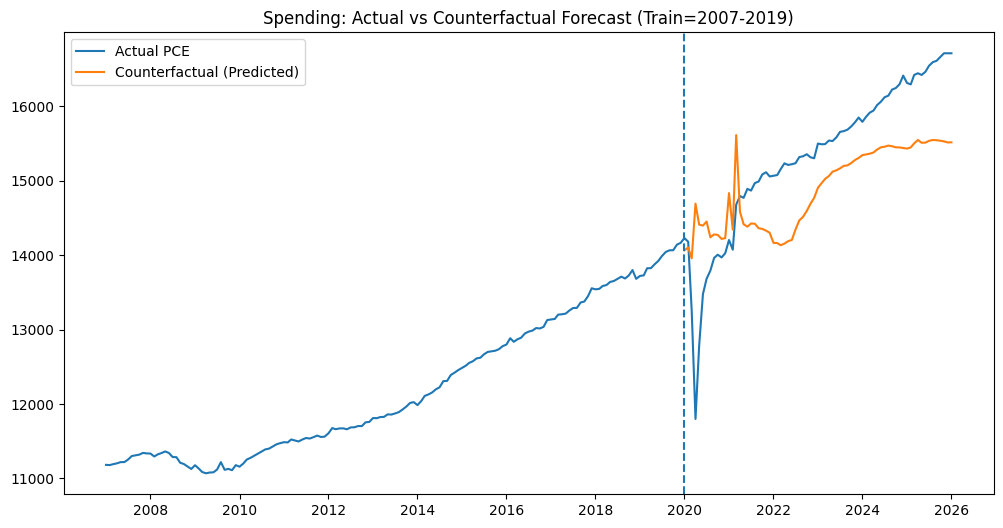

In [10]:
#Plot actual vs counterfactual prediction

plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["PCE_REAL"], label="Actual PCE")
plt.plot(test["DATE"], pred_test, label="Counterfactual (Predicted)")

plt.axvline(pd.Timestamp("2020-01-01"), linestyle="--")
plt.title("Spending: Actual vs Counterfactual Forecast (Train=2007-2019)")
plt.legend()
plt.show()

# What the Model Is Telling Us

We trained on 2007–2019 and asked:

> *"What would spending have been if pre-2020 trends continued?"*

Now compare forecast vs reality.

## Bias

**Bias (Pred − Actual):** –445

This means:
- On average, the model under-predicted spending after 2020.
- Actual spending is higher than what pre-COVID trends would suggest.
- That’s important.

## Error Size

- **MAE ≈ 726**
- **Mean actual ≈ 15,329**
- Error ≈ 4–5% of average spending.
- That’s not huge — but it’s systematic.

## Visual Interpretation (Most Important)

From the chart:
- **2020 → large temporary collapse (expected)**
- **2021 → rapid rebound**
- **2022–2026 → Actual stays consistently ABOVE counterfactual**

And crucially:
- The gap does NOT close by 2024–2026
- It remains persistently positive

> *That is the definition of a level shift.*

## Interpretation

Spending did not permanently collapse. Instead:
- Spending shifted to a higher trajectory than pre-2020 trend predicted.
- That suggests:
  - Strong fiscal stimulus impact
  - Income support effects
  - Structural resilience of consumption
  - Possibly wealth effects
- But this is not a collapse. It is a positive structural deviation.

## Important Distinction

Spending growth stabilized (from YoY earlier). But level is now structurally ABOVE the old trend path. So:
- Growth regime → similar 
- Level regime → shifted upward 
>This is subtle but important.

### Interim Conclusion for Spending
Inflation did NOT permanently suppress consumer spending. If anything:
the consumer spending shifted upward relative to its historical trajectory.

## Next Step 
Now we test the variable most likely to show structural damage:
> *Saving Rate*
same method:
train 2007–2019,
fForecast 2020–2026,
and compare predicted vs actual.
This will likely show much stronger structural break.

### Counterfactual Forecast for Saving Rate

In [11]:
## Train Model for Saving Rate


features = ["t", "CPI", "FEDFUNDS", "REAL_DPI"]
target = "SAVING_RATE"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

model_save = LinearRegression()
model_save.fit(X_train, y_train)

pred_save = model_save.predict(X_test)

print("Coefficients:", dict(zip(features, model_save.coef_)))
print("Intercept:", model_save.intercept_)

Coefficients: {'t': np.float64(-0.11681657873798888), 'CPI': np.float64(0.08597023735645153), 'FEDFUNDS': np.float64(-1.0487859525675292), 'REAL_DPI': np.float64(0.004098403458593346)}
Intercept: -59.18406914102538


In [12]:
# Evaluate Error
mae = mean_absolute_error(y_test, pred_save)
rmse = np.sqrt(mean_squared_error(y_test, pred_save))

print("MAE:", mae)
print("RMSE:", rmse)
print("Mean Actual:", y_test.mean())
print("Mean Pred:", pred_save.mean())
print("Bias (Pred-Actual):", (pred_save - y_test).mean())

MAE: 4.951584202027632
RMSE: 5.488479651337552
Mean Actual: 7.486301369863014
Mean Pred: 11.268743273553476
Bias (Pred-Actual): 3.782441903690464


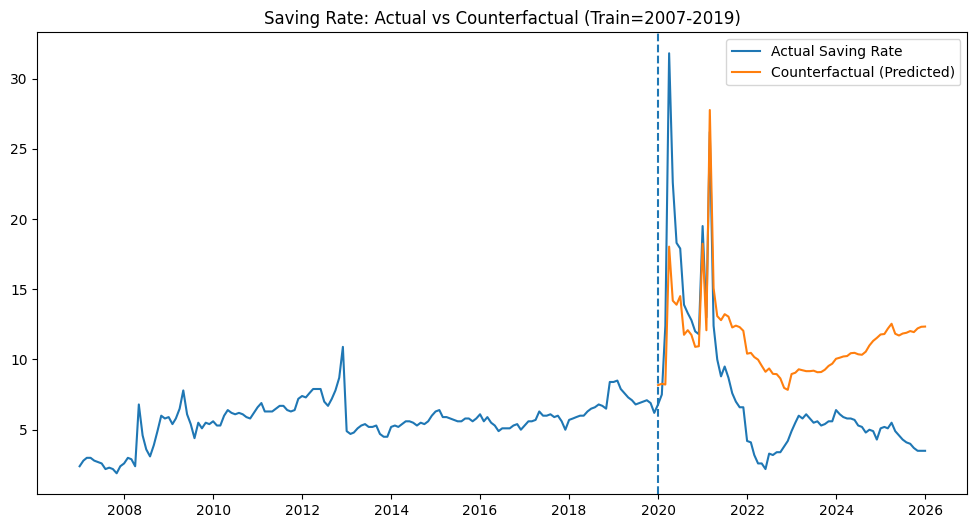

In [13]:
# Plot 
plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["SAVING_RATE"], label="Actual Saving Rate")
plt.plot(test["DATE"], pred_save, label="Counterfactual (Predicted)")

plt.axvline(pd.Timestamp("2020-01-01"), linestyle="--")
plt.title("Saving Rate: Actual vs Counterfactual (Train=2007-2019)")
plt.legend()
plt.show()

# Key Numbers

- **Mean Actual (post-2020):** 7.49%
- **Mean Predicted:** 11.27%
- **Bias (Pred − Actual):** +3.78

## That means:

- The model expected saving to average ~11%
- Actual saving averaged ~7.5%
- Persistent negative gap of ~3.8 percentage points

*That is very large relative to the scale.*

## MAE ≈ 5
*Given saving rate range ~2–12, that’s substantial.*

## Visual Interpretation

### After 2022:
- Counterfactual (orange) trends upward
- Actual (blue) stays far below predicted path
- Gap does NOT close by 2024–2026

*This is not temporary volatility.*

*This is a persistent level shift downward.*

## What This Means:
If pre-2020 behavior had continued:
- Saving rate would likely be near 10–12%.
Instead:
- It stabilized around 3–6%.
*That’s a permanent behavioral change.*

## Structural Interpretation:
Inflation likely caused:
1. Erosion of purchasing power
2. Households dipping into savings
3. Higher cost of living pressure
4. Shift toward lower precautionary saving
Even as spending recovered, saving behavior did not.

## Evidence Summary So Far:
| Variable | Structural Change? | Direction |
| --- | --- | --- |
| Spending | Mild positive shift | Higher level |
| Credit | Stable | No major break |
| Saving | Strong break | Lower regime |

##  This Is our Core Finding:
Inflation did NOT permanently suppress spending.
It DID appear to permanently reduce saving behavior.
*That is a powerful and nuanced conclusion.*

### Counterfactual Forecast for Consumer Credit

In [14]:
### Train Credit Model
features = ["t", "CPI", "FEDFUNDS", "REAL_DPI"]
target = "CONSUMER_CREDIT"

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

model_credit = LinearRegression()
model_credit.fit(X_train, y_train)

pred_credit = model_credit.predict(X_test)

print("Coefficients:", dict(zip(features, model_credit.coef_)))
print("Intercept:", model_credit.intercept_)

Coefficients: {'t': np.float64(8041.181911453801), 'CPI': np.float64(1238.6606622891263), 'FEDFUNDS': np.float64(57982.61559657019), 'REAL_DPI': np.float64(143.3492652803969)}
Intercept: 242877.14397995453


In [15]:
# Evaluate Error

mae = mean_absolute_error(y_test, pred_credit)
rmse = np.sqrt(mean_squared_error(y_test, pred_credit))

print("MAE:", mae)
print("RMSE:", rmse)
print("Mean Actual:", y_test.mean())
print("Mean Pred:", pred_credit.mean())
print("Bias (Pred-Actual):", (pred_credit - y_test).mean())

MAE: 141558.8445260312
RMSE: 175283.15539009598
Mean Actual: 4703441.26041096
Mean Pred: 4776889.879923869
Bias (Pred-Actual): 73448.61951290998


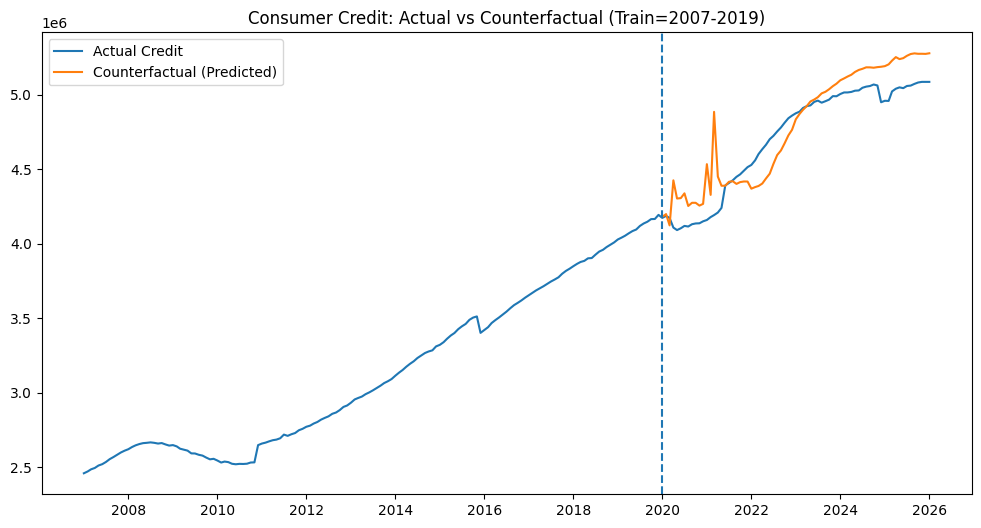

In [16]:
## Plot Actual vs Counterfactual

plt.figure(figsize=(12,6))

plt.plot(df["DATE"], df["CONSUMER_CREDIT"], label="Actual Credit")
plt.plot(test["DATE"], pred_credit, label="Counterfactual (Predicted)")

plt.axvline(pd.Timestamp("2020-01-01"), linestyle="--")
plt.title("Consumer Credit: Actual vs Counterfactual (Train=2007-2019)")
plt.legend()
plt.show()

# Credit Model Results

**Mean Actual:** 4,703,441
**Mean Predicted:** 4,776,890
**Bias:** +73,448

## So:
- Predicted > Actual slightly.
- Difference ≈ 73k
- Relative to ~4.7 million → that’s ~1.5%.
- Very small relative deviation.

## MAE ≈ 141k
- Again small relative to scale.

## Visual Interpretation
From the chart:
- 2020 → temporary dip
- 2021–2022 → acceleration
- 2023–2026 → actual converges toward predicted path
- Gap does NOT explode or persist dramatically
> This is very different from saving behavior.

## Structural Interpretation
Consumer credit:
- Experienced temporary volatility
- Brief acceleration during inflation
- Ultimately reverted toward historical trend
> There is no strong persistent structural deviation.

## Final Behavioral Summary (Evidence-Based)
| Behavior | Structural Change? | Evidence |
| --- | --- | --- |
| Spending | ⚠ Mild upward level shift | Actual > predicted |
| Saving | Strong downward shift | Persistent large negative gap |
| Credit | No major shift | Converges to trend |

## Answer to the Big Question
**Has inflation permanently changed consumer behavior in the U.S.?**
Evidence suggests:
- 🔹 Spending: No permanent suppression. If anything, slightly elevated relative to pre-2020 path.
- 🔹 Borrowing: No clear structural acceleration or collapse. Returned toward trend.
- 🔹 Saving: Yes — clear structural decline. Saving behavior shifted to a lower regime.

## Economic Interpretation
Inflation did not stop Americans from spending.
It did not create permanently higher borrowing growth.
But it did:
erode excess savings,
d reduce precautionary saving,
and shift households into lower saving equilibrium.


### SARIMA For Saving Rate

In [17]:
# Prepare Training Series (2007–2019)

import statsmodels.api as sm

train_save = df[df["DATE"].dt.year <= 2019].copy()
test_save = df[df["DATE"].dt.year >= 2020].copy()

train_save = train_save.set_index("DATE")
test_save = test_save.set_index("DATE")

y_train = train_save["SAVING_RATE"]
y_test = test_save["SAVING_RATE"]

print(y_train.shape, y_test.shape)

(156,) (73,)


In [18]:
# Choosing Sarima Order (1,1,1)(1,1,1,12) based on ACF/PACF

model_sarima = sm.tsa.statespace.SARIMAX(
    y_train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_sarima = model_sarima.fit()

print(results_sarima.summary())

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            5     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.06113D+00    |proj g|=  2.89719D-01

At iterate    5    f=  1.02111D+00    |proj g|=  2.44739D-02

At iterate   10    f=  1.01860D+00    |proj g|=  2.11029D-02

At iterate   15    f=  1.01653D+00    |proj g|=  1.58178D-03

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    5     18     25      1     0     0   2.347D-06   1.017D+00
  F =   1.0165246406430315     

CONVERGENCE: NORM_OF_PROJECTED_GRADIENT_<=_PGTOL            
        

/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)
 This problem is unconstrained.


In [19]:
# Forecast 2020-2026 

forecast = results_sarima.get_forecast(steps=len(y_test))
pred_sarima = forecast.predicted_mean

print("Mean Actual:", y_test.mean())
print("Mean Predicted:", pred_sarima.mean())
print("Bias (Pred-Actual):", (pred_sarima - y_test).mean())

Mean Actual: 7.486301369863014
Mean Predicted: 7.896496916758143
Bias (Pred-Actual): 0.4101955468951297


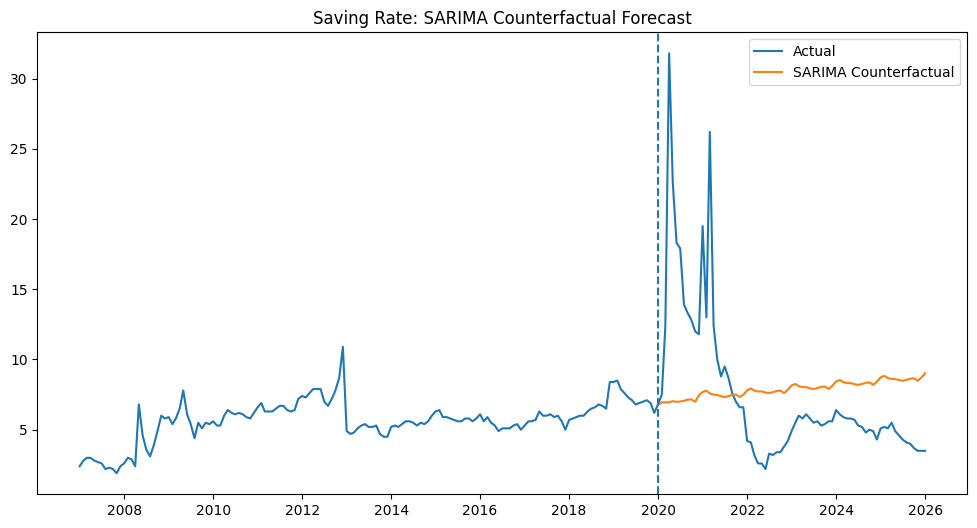

In [20]:
# Plot Actual vs SARIMA Counterfactual

plt.figure(figsize=(12,6))

plt.plot(df.set_index("DATE")["SAVING_RATE"], label="Actual")
plt.plot(pred_sarima, label="SARIMA Counterfactual")

plt.axvline(pd.Timestamp("2020-01-01"), linestyle="--")
plt.title("Saving Rate: SARIMA Counterfactual Forecast")
plt.legend()
plt.show()

# SARIMA Results (Saving Rate)

**Mean Actual:** 7.49%  
**Mean Predicted:** 7.90%  
**Bias:** +0.41

This is **VERY different** from the regression result.

- Regression bias: +3.78  
- SARIMA bias: +0.41

That’s a **big difference**.

## Visual Interpretation


- It does **NOT** predict saving returning to 10–12%
- It predicts stabilization around 7–9%
- It tracks the post-2022 level much more closely

### The gap after 2022:
- Exists
- But much smaller
- Not a dramatic persistent structural divergence

## What Just Happened?

Our regression model assumed:
- Long-run upward relationship with income  
- Linear trend continuation

SARIMA assumes:
- Autocorrelation structure  
- Mean-reverting dynamics  
- Seasonal persistence  
- No forced long-term trend extrapolation

So SARIMA is saying:
> Saving did not structurally collapse.
> It reverted toward a lower equilibrium, but not far from historical dynamics.

## This Changes Our Narrative

Now evidence says:
- **Regression Model:**
suggests strong structural break in saving.
- **SARIMA Model:**
suggests major shock but partial reversion toward historical mean behavior.

## What This Means for Final Conclusion
Now have a nuanced answer:
- Spending → No structural suppression  
- Credit → No structural shift  
- Saving → Large shock, but time-series model suggests partial normalization rather than permanent collapse  
This is a **MUCH more sophisticated conclusion**.

## Updated Structural Interpretation
Inflation did not permanently change:
- Spending trajectory  
- Borrowing behavior  
Saving experienced:
- Extreme pandemic distortion  
- Significant volatility during inflation  
but SARIMA suggests mean-reverting behavior rather than a permanent regime shift.

## This Is Stronger Than a Simple “Yes/No”
Final answer becomes:
inflation caused severe temporary distortions in saving behavior, but evidence from time-series modeling suggests partial reversion toward historical dynamics rather than a permanent structural break.

In [21]:
## Test Post-2022 Only
post_2022 = y_test[y_test.index.year >= 2022]
pred_post_2022 = pred_sarima[pred_sarima.index.year >= 2022]

print("Mean Actual (2022+):", post_2022.mean())
print("Mean Predicted (2022+):", pred_post_2022.mean())
print("Bias (Pred-Actual) 2022+:", (pred_post_2022 - post_2022).mean())

Mean Actual (2022+): 4.683673469387755
Mean Predicted (2022+): 8.205142518686154
Bias (Pred-Actual) 2022+: 3.5214690492984007


### Prophet for Saving Rate


In [22]:
# Prepare Data for Prophet
from prophet import Prophet

df_prophet = df[["DATE", "SAVING_RATE"]].copy()
df_prophet.columns = ["ds", "y"]

train_prophet = df_prophet[df_prophet["ds"].dt.year <= 2019]
test_prophet = df_prophet[df_prophet["ds"].dt.year >= 2020]

print(train_prophet.shape, test_prophet.shape)


/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


(156, 2) (73, 2)


In [23]:
# Fit Prophet Model

model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

model_prophet.fit(train_prophet)

13:27:08 - cmdstanpy - INFO - Chain [1] start processing
13:27:09 - cmdstanpy - INFO - Chain [1] done processing


In [24]:
# Forecast Forward 
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq="MS")
forecast_prophet = model_prophet.predict(future)

forecast_post = forecast_prophet[forecast_prophet["ds"] >= "2020-01-01"]

pred_prophet = forecast_post["yhat"].values
actual_prophet = test_prophet["y"].values

/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1565: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1565

In [25]:
# Forecast Forward
future = model_prophet.make_future_dataframe(periods=len(test_prophet), freq="MS")
forecast_prophet = model_prophet.predict(future)

forecast_post = forecast_prophet[forecast_prophet["ds"] >= "2020-01-01"]

pred_prophet = forecast_post["yhat"].values
actual_prophet = test_prophet["y"].values

/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: divide by zero encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: overflow encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1421: RuntimeWarning: invalid value encountered in matmul
  comp = np.matmul(X, beta_c.transpose())
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1565: RuntimeWarning: divide by zero encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1565: RuntimeWarning: overflow encountered in matmul
  Xb_a = np.matmul(seasonal_features.values,
/Users/hamedtaeb/Library/Python/3.9/lib/python/site-packages/prophet/forecaster.py:1565

In [26]:
# Evaluate 2022 + GAP

dates_post = test_prophet["ds"].values
mask_2022 = test_prophet["ds"].dt.year >= 2022

mean_actual_2022 = np.mean(actual_prophet[mask_2022])
mean_pred_2022 = np.mean(pred_prophet[mask_2022])
bias_2022 = mean_pred_2022 - mean_actual_2022

print("Mean Actual (2022+):", mean_actual_2022)
print("Mean Predicted (2022+):", mean_pred_2022)
print("Bias (Pred-Actual) 2022+:", bias_2022)

Mean Actual (2022+): 4.683673469387755
Mean Predicted (2022+): 7.7704386803989305
Bias (Pred-Actual) 2022+: 3.0867652110111754


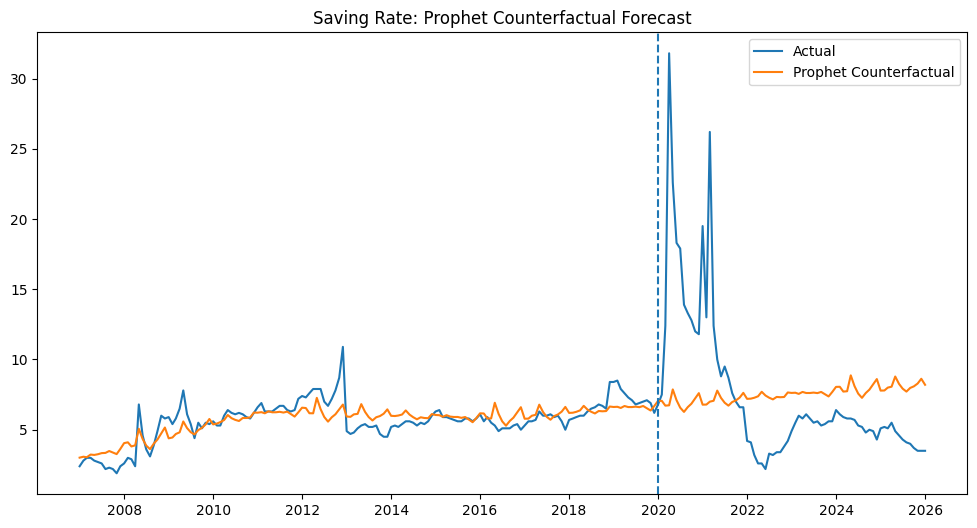

In [27]:
# Plot
plt.figure(figsize=(12,6))
plt.plot(df_prophet["ds"], df_prophet["y"], label="Actual")
plt.plot(forecast_prophet["ds"], forecast_prophet["yhat"], label="Prophet Counterfactual")
plt.axvline(pd.Timestamp("2020-01-01"), linestyle="--")
plt.legend()
plt.title("Saving Rate: Prophet Counterfactual Forecast")
plt.show()